# Twinned FCC 3D Pipeline: Basic Walkthrough (Annotated)

Equivalent in scope to `twinned_fcc_bas0.ipynb`, with two additions: a
brief statement of purpose preceding each stage, and terminology (MDF,
CSL, temporal slice) defined at first use. An optional `QUICK_DEMO` flag
(Part A) reduces the Monte Carlo domain size for faster execution during
initial review.

Related notebooks: `twinned_fcc_bas0.ipynb` (unannotated equivalent),
`twinned_fcc_int0.ipynb` (full pipeline with validation plots and exposed
parameters), and `twinned_fcc_adv0.ipynb` (extended parameter exposure).

**Pipeline stages**: EBSD analysis, Monte Carlo base grain structure
generation, representativeness assessment and qualification, host
allocation, orientation assignment, twin generation, post-twin validation,
and visualization/export. The Voronoi and image-import base-structure
paths are not covered; Monte Carlo is the default generation method
throughout.

Parameter defaults correspond to values validated against the reference
dataset used in this notebook.

## Part A: Start (Global Configuration)

This stage establishes the pipeline output directory and opens the report
session to which every subsequent stage appends its results.

The report session (`upxo.reporting.ReportSession`) accumulates outputs,
including raw exports, Abaqus mesh files, and the rendered report, under
`<output_dir>/TwinnedFCC/...`.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

from upxo.pxtal.twinned_simple_3d.steps import (
    steps_start, steps_ebsd_analysis_1, steps_self_repr_1, steps_ebsd_analysis_2,
    steps_base_grain_structure_mc, steps_repr_assessment_qualification,
    steps_transformations, steps_host_allocation, steps_pre_twin_validation,
    steps_orientation_assignment, steps_twin_generation, steps_post_twin_validation,
    steps_distribution_viewer, steps_subsetting, steps_visualization_export,
)

In [2]:
RESEARCHER_NAME = ""
ORGANISATION = ""
EMAIL = ""
MATERIAL_NAME = "OFHC Copper"
PROCESSING_CONDITION = ""

report = steps_start.open_pipeline_report(
    researcher_name=RESEARCHER_NAME, organisation=ORGANISATION, email=EMAIL,
    material_name=MATERIAL_NAME, processing_condition=PROCESSING_CONDITION,
    notebook_tag='bas1')
report

### Quick-Demo Mode (Optional)

Setting `QUICK_DEMO = True` reduces the Monte Carlo domain size and step
count in Part F, substantially decreasing execution time for an initial
pass through the notebook. Results obtained under this setting do not
closely reproduce the reference EBSD data; restore `QUICK_DEMO = False`
(the default, matching the domain used in `twinned_fcc_bas0.ipynb`) for a
physically meaningful run.

In [3]:
QUICK_DEMO = False   # True = smaller/faster domain for a first read-through; False = full, physically meaningful run

## Part B: EBSD Analysis-1

This stage establishes the reference microstructure against which the
entire pipeline is calibrated; all downstream measurements trace back to
the data characterised here.

Loads the reference EBSD map (subsampled by default, as grain detection on
full-resolution maps is computationally expensive), performs grain
detection, and trims a one-percent border to avoid edge artefacts.
Produces the `repgen2d` object (`rg`) used throughout the remainder of the
pipeline.

In [4]:
CTF_FILE = steps_ebsd_analysis_1.DEFAULT_CTF_FILE
STRIDE_X, STRIDE_Y = 5, 5   # default subsampling

rdr = steps_ebsd_analysis_1.subsample_and_load(
    CTF_FILE, subsample=True, stride_x=STRIDE_X, stride_y=STRIDE_Y, reuse_subsampled=True)

Loaded EBSD data (dimensions: 206 x 146 pixels, step size: 2.0 um)
Finished building quaternion array (0:00:00) 


In [5]:
MIN_GRAIN_SIZE_DETECT = 10   # pixels
MISORI_TOL = 10.0           # degrees
rdr = steps_ebsd_analysis_1.detect_grains(rdr, min_grain_size=MIN_GRAIN_SIZE_DETECT, misori_tol=MISORI_TOL)

Finished finding grain boundaries (0:00:00) 
Finished finding grains (0:00:00) 


In [6]:
rdr = steps_ebsd_analysis_1.crop(rdr, xstart_pct=1.0, ystart_pct=1.0, xend_pct=99.0, yend_pct=99.0)

[crop] region=[1.0, 1.0, 99.0, 99.0]%  ->  rows 1:145, cols 2:204  |  original 146x206  ->  cropped 144x202


In [7]:
rg = steps_ebsd_analysis_1.clean_and_characterize(rdr, ctf_file=CTF_FILE)

[rechar_lfi] Map 144×202  |  unknown pixels: 2997 (10.30%)  |  connectivity=4
[rechar_lfi] Step 1/5 — labelling unknown connected components …
[rechar_lfi]           652 connected components found.
[rechar_lfi] Step 2/5 — computing grain adjacency …
[rechar_lfi] Step 3/5 — assigning CC pixels to grains …


  assigning CCs:   0%|          | 0/652 [00:00<?, ?CC/s]

[rechar_lfi]           652/652 CCs assigned (2997 pixels filled).
[rechar_lfi] Step 4/5 — computing grain-average orientations (vectorized) …
[rechar_lfi]           189 unique grains to average over.
[rechar_lfi]           averaging Euler channels (3) …
[rechar_lfi]           averaging quaternion channels (4) …
[rechar_lfi]           orientation averages ready.
[rechar_lfi] Step 5/5 — writing orientations for 2997 unknown pixels (vectorised, no loop) …
[rechar_lfi]           2997 pixels written (0 isolated islands left unfilled).
[rechar_lfi] Done.
clean_and_rechar_from_rdr() completed in 1.0 s
Non-positive pixels remaining : 0
Grains after cleaning         : 522
Neighbour entries             : 522
prop_ebsd grain count         : 522
Property                      mean         std         min         max   count
---------------------------------------------------------------------------
area                       222.897     313.470       8.000    2628.000     522
perimeter             

## Part C: Self-Representativeness-1 (Omitted)

An optional self-representativeness study of the EBSD domain, omitted here
for brevity. See `twinned_fcc_int0.ipynb` or `twinned_fcc_adv0.ipynb` for
the complete analysis.

## Part D: EBSD Analysis-2

This stage establishes the target quantities used throughout the
remainder of the pipeline: the number of twins, their thickness, and their
distribution across generations.

The most computationally intensive stage of the analysis. Computes the
misorientation distribution function (**MDF**, a histogram of the angular
mismatch between neighbouring grains' crystal orientations) and detects
candidate **CSL** (coincidence-site-lattice) peaks, grain-boundary types
at which the two adjoining lattices share partial coincidence at a
specific misorientation angle; Sigma3 denotes the twin boundary type.
Parent/twin grain pairs are segregated about the Sigma3 peak, the twin
role of every grain is classified, the twin volume fraction is partitioned
into Stage-1/Stage-2a/Stage-2b targets, and twin lamella thickness is
measured. The resulting quantities (`parent_info`, `vf_targets`,
`twin_thickness`) constitute inputs to nearly every subsequent stage.

In [8]:
mdf, peaks = steps_ebsd_analysis_2.compute_mdf_and_peaks(rg)
selected_peaks = steps_ebsd_analysis_2.select_all_peaks(peaks)   # keep every detected peak
len(selected_peaks['indices'])

--------------------Detected peaks---------------------
  15.5°  (density=0.0043)
  21.5°  (density=0.0115)
  28.5°  (density=0.0115)  ~ S13b (delta=+0.7 deg)
  31.5°  (density=0.0237)
  35.5°  (density=0.0337)  ~ S5 (delta=-1.4 deg)
  38.5°  (density=0.0602)  ~ S7 (delta=+0.3 deg)
  41.5°  (density=0.0244)
  45.5°  (density=0.0330)
  48.5°  (density=0.0222)  ~ S11 (delta=-2.0 deg)
  51.5°  (density=0.0280)  ~ S11 (delta=+1.0 deg)
  54.5°  (density=0.0222)
  59.5°  (density=0.2315)  ~ S3  (twin) (delta=-0.5 deg)


12

CSL type            ref °   pairs   grains
------------------------------------------
S13b                27.80      50       89
S5                  36.87     155      219
S7                  38.21     200      266
S11                 50.48     128      189
S3  (twin)          60.00     361      432
CSL type            ref °   pairs   pure parents   pure twins   intermediates
---------------------------------------------------------------------------
S13b                27.80      50             43           44               2
S5                  36.87     155             89          106              24
S7                  38.21     200            100          135              31
S11                 50.48     128             76           95              18
S3  (twin)          60.00     361            141          210              81
[merge_info]  merged grains: 105  |  with twins: 90  |  twin-hosting fraction: 0.8571


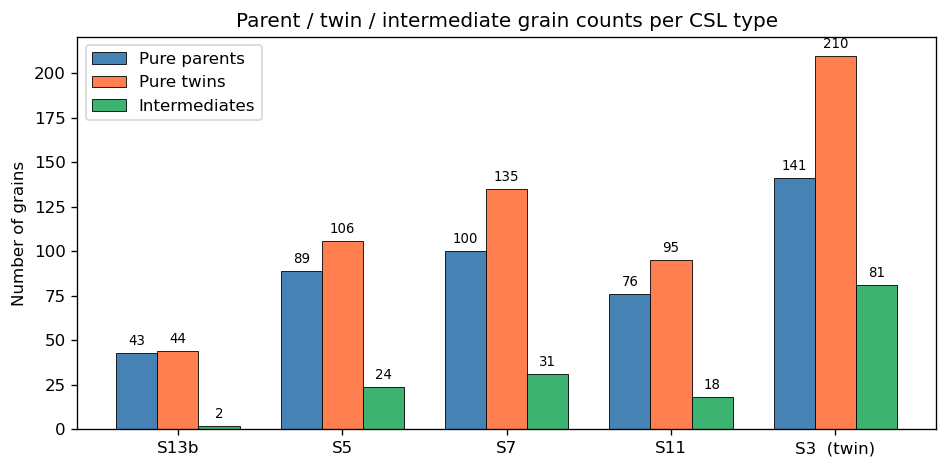

In [9]:
csl_grains = steps_ebsd_analysis_2.segregate_csl_pairs(rg, mdf, peaks, selected_peaks)
parent_info = steps_ebsd_analysis_2.identify_parent_grains(rg, csl_grains)

In [10]:
CSL_LABEL = steps_ebsd_analysis_2.DEFAULT_CSL_LABEL   # 'S3  (twin)'
tvf_by_label = steps_ebsd_analysis_2.compute_twin_area_fractions(rg, parent_info, csl_labels=(CSL_LABEL,))
tvf_by_label[CSL_LABEL]

{'csl_label': 'S3  (twin)',
 'total_area': np.float64(116352.0),
 'pure_parent_frac': np.float64(0.5133388338833883),
 'primary_twin_frac': np.float64(0.13675742574257427),
 'secondary_twin_frac': np.float64(0.048336083608360836),
 'intermediate_frac': np.float64(0.17175467546754675),
 'overall_twin_frac': np.float64(0.35684818481848185),
 'non_role_frac': np.float64(0.12981298129812982),
 'extended_info': {'S13b': {'pairs_labeled': [(25, 15),
    (52, 65),
    (66, 53),
    (69, 78),
    (93, 78),
    (98, 101),
    (131, 152),
    (136, 160),
    (136, 161),
    (147, 232),
    (150, 187),
    (151, 178),
    (157, 152),
    (158, 234),
    (167, 163),
    (170, 169),
    (207, 170),
    (181, 276),
    (215, 186),
    (236, 188),
    (189, 221),
    (209, 222),
    (231, 214),
    (216, 241),
    (291, 225),
    (241, 274),
    (291, 315),
    (329, 304),
    (314, 345),
    (351, 316),
    (319, 345),
    (320, 322),
    (320, 358),
    (337, 323),
    (339, 324),
    (351, 327),
 

In [11]:
role_props = steps_ebsd_analysis_2.compute_grain_role_properties(rg, parent_info, selected_props=('area',))
vf_partition, vf_targets = steps_ebsd_analysis_2.compute_vf_partition(rg, parent_info, tvf_by_label, csl_label=CSL_LABEL)
vf_targets

compute_ebsd_twin_vf_partition  (CSL: S3  (twin))
  Intermediates (primary twins) :   81  VF=0.1718
  Type-2a pure twins (outward)  :  199  VF=0.1807
  Type-2b pure twins (inward)   :   11  VF=0.0044
  SGC Stage-1 carving target    :       VF=0.1762  (intermediate + 2b)
  Derived prob_secondary_outward: 0.976


{'tvf_stage1': np.float64(0.308512101210121),
 'tvf_secondary_2a': np.float64(0.024168041804180418),
 'tvf_secondary_2b': np.float64(0.024168041804180418),
 'prob_secondary_outward': 0.5}

In [12]:
twin_thickness = steps_ebsd_analysis_2.compute_twin_thickness(rg, parent_info)
twin_thickness['mean'], twin_thickness['median']

  Twin thickness (minor_axis_length) and intercept statistics (EBSD):
  Metric                              Q1    Q2 (med)        Q3       IQR
  ----------------------------------------------------------------------
  Thickness (µm)                   11.92       16.33     24.00     12.07
  Intercept length (px)             1.00        1.00      5.00      4.00
  Linear intercept (px), X,Y,Z      3.00        8.00     16.25     13.25
  Abrupt twins: 261 / 417  (fraction = 0.633)
  N = 414  |  CV = 0.586  |  skewness = 2.006  |  kurtosis (excess) = 5.706


(19.640914480154372, 16.327818332377632)

In [13]:
report.add_table([vf_targets], title='EBSD VF Targets', section='EBSD Analysis-2')
twin_thickness_summary = {k: v for k, v in twin_thickness.items() if not hasattr(v, '__len__') or isinstance(v, str)}
report.add_table([twin_thickness_summary], title='EBSD Twin Thickness Statistics', section='EBSD Analysis-2')

TableEntry(id=3, timestamp='2026-09-16T10:18:38', title='EBSD Twin Thickness Statistics', columns=['col', 'step_um', 'mean', 'median', 'std', 'min', 'max', 'pct10', 'pct90', 'n_abrupt_ebsd', 'abrupt_frac_ebsd', 'intercept_q1', 'intercept_q2', 'intercept_q3', 'linear_intercept_q1', 'linear_intercept_q2', 'linear_intercept_q3', 'n_twins', 'thick_q1', 'thick_q3', 'skewness', 'kurtosis', 'cv'], rows=[['minor_axis_length', 2.0, 19.640914480154372, 16.327818332377632, 11.514843716806029, 5.563157194476387, 86.26351579373421, 9.196966294519228, 34.199942654757976, 261, 0.633495145631068, 1.0, 1.0, 5.0, 3.0, 8.0, 16.25, 414, 11.922281209038562, 23.996926093381504, 2.0058126991077323, 5.705684439976867, 0.5862682070349061]], caption=None, section='EBSD Analysis-2', source_page=None)

## Part E: Self-Representativeness-3 (Omitted)

Texture and pole-figure analysis for this stage remains unimplemented in
the current package; no functional code exists to wrap. Consistent with
the `twinned_simple_3d` package documentation, which advises against
placeholder implementations for production studies, no
`steps_self_repr_3.py` module or corresponding cell is provided here.

## Part F: Base Grain Structure (Monte Carlo)

This stage generates the untwinned three-dimensional grain structure from
which host grains are subsequently selected and into which twins are
later introduced.

Method selection is unambiguous on this path: Monte Carlo is the
base-grain-structure generation method addressed in this notebook,
distinct from the Voronoi and image-import paths, which are not covered
here. Executes a three-dimensional Potts-model Monte Carlo grain-growth
simulation and computes the labelled feature index (grain labels) for
every stored **temporal slice**, a snapshot of the simulated grain
structure at a given simulation step; earlier steps comprise many small,
minimally grown grains, while later steps comprise fewer, larger, more
fully annealed grains. Each slice is then cleaned (merging undersized
grains, removing single-voxel spikes).

In [14]:
MC_DOMAIN_EDGE = 25.0 if QUICK_DEMO else 50.0   # voxels per domain edge
MC_STEPS = 40 if QUICK_DEMO else 100            # Monte Carlo simulation steps

# NOTE: the full-size run (QUICK_DEMO=False, the default) can take a while --
# QUICK_DEMO=True trades physical realism for a much faster first pass.
pxt = steps_base_grain_structure_mc.run_mc_simulation(
    xmax=MC_DOMAIN_EDGE, ymax=MC_DOMAIN_EDGE, zmax=MC_DOMAIN_EDGE, q_states=10,
    mcsteps=MC_STEPS, save_interval=5, mcalg='300b', consider_boltzmann=True,
    boltzmann_temp_factor=0.01, rng_seed=0)

Algo_hops details
(('300b', 100),)
[False]
Initiating grain growth
----------------------------------------
GS temporal slice 0 stored
GS temporal slice 5 stored
GS temporal slice 10 stored
GS temporal slice 15 stored
GS temporal slice 20 stored
GS temporal slice 25 stored
GS temporal slice 30 stored
GS temporal slice 35 stored
GS temporal slice 40 stored
GS temporal slice 45 stored
GS temporal slice 50 stored
GS temporal slice 55 stored
GS temporal slice 60 stored
GS temporal slice 65 stored
GS temporal slice 70 stored
GS temporal slice 75 stored
GS temporal slice 80 stored
GS temporal slice 85 stored
GS temporal slice 90 stored
GS temporal slice 95 stored
|--------------- MC SIM RUN COMPLETED on: ALG310---------------|
Number of gs tslices: 20


In [15]:
lfi = steps_base_grain_structure_mc.calculate_lfi(pxt)

---------------------------------------- 
Finding grains.
No. of grains detected = 48247
---------------------------------------- 
Setting PyVista grid.
---------------------------------------- 
Adding scalar field: lgi to PyVista grid self.pvgrid.
Access: self.pvgrid.cell_data['lgi']

Finding voxel locations of grains in lgi.

Finding normal and extended spatial bounds of all grains.
Completed ----------------------------------------
----------------------------------------
---------------------------------------- 
Setting grain volumes (metric: 'volnv') -> 
Grain volumes (metric: 'volnv') -> : have been set.
 ----------------------------------------
  t=0: 48247 grain(s)
---------------------------------------- 
Finding grains.
No. of grains detected = 1960
---------------------------------------- 
Setting PyVista grid.
---------------------------------------- 
Adding scalar field: lgi to PyVista grid self.pvgrid.
Access: self.pvgrid.cell_data['lgi']

Finding voxel locations of grain

In [16]:
cumulative_summary, n_passes_run = steps_base_grain_structure_mc.clean_structure(pxt, min_grain_size=4, start_index=1)
n_passes_run

-- Clean pass 1/5 --
  t=5: merged 1059 small grain(s), removed 4148 spike voxel(s)
  t=10: merged 316 small grain(s), removed 1802 spike voxel(s)
  t=15: merged 167 small grain(s), removed 1099 spike voxel(s)
  t=20: merged 104 small grain(s), removed 927 spike voxel(s)
  t=25: merged 100 small grain(s), removed 678 spike voxel(s)
  t=30: merged 83 small grain(s), removed 558 spike voxel(s)
  t=35: merged 71 small grain(s), removed 470 spike voxel(s)
  t=40: merged 66 small grain(s), removed 393 spike voxel(s)
  t=45: merged 51 small grain(s), removed 349 spike voxel(s)
  t=50: merged 43 small grain(s), removed 336 spike voxel(s)
  t=55: merged 34 small grain(s), removed 289 spike voxel(s)
  t=60: merged 32 small grain(s), removed 254 spike voxel(s)
  t=65: merged 36 small grain(s), removed 265 spike voxel(s)
  t=70: merged 41 small grain(s), removed 248 spike voxel(s)
  t=75: merged 35 small grain(s), removed 226 spike voxel(s)
  t=80: merged 29 small grain(s), removed 211 spike voxe

5

## Part G: Representativeness Assessment and Qualification

This stage selects, from the many candidate structures produced by the Monte Carlo simulation (one per stored temporal slice), the structure that best matches the reference EBSD data.

Ranks every stored Monte Carlo temporal slice against the EBSD
parent-grain reference (two-dimensional cross-sections compared with the
EBSD map), re-assesses candidates under the configured tolerances, and
selects the single best-matching slice as the authoritative structure for
host allocation. The physical scale factor (um/voxel) of the selected
slice is calibrated in the same step.

Ranking begins at slice index 1 rather than 0: slice 0 represents the
Monte Carlo simulation's un-annealed seed state (a grain count equal to
the voxel count, with no growth), which is not a meaningful
synthetic-structure candidate. Its disproportionately large grain count
can otherwise dominate the shortlist under certain criteria despite
representing the poorest overall match. The Base Grain Structure cleaning
step already excludes this slice (`start_index=1`) for the same reason.

In [17]:
candidates = steps_repr_assessment_qualification.rank_slices(
    pxt, parent_info=parent_info, role_props=role_props, start=1)
len(candidates)

  [1/19] tslice=5 ...  2D-avg grains=128.3 (n_slices=15, ratio=0.91)  3D grains=829 (face=481, interior=348)  |  pooled: area(n=1925)
  [2/19] tslice=10 ...  2D-avg grains=90.1 (n_slices=15, ratio=0.64)  3D grains=549 (face=351, interior=198)  |  pooled: area(n=1352)
  [3/19] tslice=15 ...  2D-avg grains=72.9 (n_slices=15, ratio=0.52)  3D grains=419 (face=287, interior=132)  |  pooled: area(n=1094)
  [4/19] tslice=20 ...  2D-avg grains=62.6 (n_slices=15, ratio=0.44)  3D grains=340 (face=246, interior=94)  |  pooled: area(n=939)
  [5/19] tslice=25 ...  2D-avg grains=55.2 (n_slices=15, ratio=0.39)  3D grains=289 (face=214, interior=75)  |  pooled: area(n=828)
  [6/19] tslice=30 ...  2D-avg grains=49.2 (n_slices=15, ratio=0.35)  3D grains=241 (face=190, interior=51)  |  pooled: area(n=738)
  [7/19] tslice=35 ...  2D-avg grains=45.6 (n_slices=15, ratio=0.32)  3D grains=207 (face=163, interior=44)  |  pooled: area(n=684)
  [8/19] tslice=40 ...  2D-avg grains=42.3 (n_slices=15, ratio=0.30)  

19

In [18]:
candidates = steps_repr_assessment_qualification.reassess_candidates(pxt, candidates, role_props)

In [19]:
rows, best_row = steps_repr_assessment_qualification.shortlist_and_select(candidates, role_props)
best_row['tslice_key'] if best_row else None

5

In [20]:
scale_factor = steps_repr_assessment_qualification.apply_selected_scale_factor(pxt, best_row)
tslice_key = best_row['tslice_key']
scale_factor

4.011390934702663

In [21]:
report.add_table([rows[0]] if rows else [{}], title='Temporal Slice Shortlist', section='Repr. assess. & qualification')

TableEntry(id=5, timestamp='2026-09-16T10:18:46', title='Temporal Slice Shortlist', columns=['tslice_key', 'n_stars', 'aggregate_score', 'scale_factor', 'implied_rve_size_um', 'star_rank', 'score_rank', 'coupled_rank'], rows=[[5, 1, 0.9102501448186244, 4.011390934702663, (204.58093766983583, 204.58093766983583, 204.58093766983583), 1, 1, 1]], caption=None, section='Repr. assess. & qualification', source_page=None)

## Part H: Transformations (Omitted)

An optional non-equiaxiality rescale/stretch of the base structure,
omitted in this basic walkthrough; the identity transform (no
modification) is applied throughout. See
`twinned_fcc_int0.ipynb`/`twinned_fcc_adv0.ipynb` to enable this stage.

## Part I: Host Allocation

This stage determines which grains are eligible to host a twin, and in what number.

Allocates which grains within the base structure become twin "hosts", via
a maximal-independent-set-constrained spatial selection targeting a
specified volume fraction, then re-assesses the result through
two-dimensional cross-sections for comparability with the EBSD
two-dimensional hosting-fraction target.

`HOST_TARGET_FRACTION` is a grain-count fraction, derived from EBSD's
`twin_hosting_fraction` (the fraction of parent grains hosting a twin),
not an area or volume fraction; the achieved hosting fraction reported
below is, by contrast, a volume fraction, and the two quantities are
therefore not directly comparable. The volume captured by a given
grain-count selection depends strongly on `HOST_RANKING_VOLUME_WEIGHT` and
`HOST_POOL_B_BAND_SHAPE`: ranking purely by volume (1.0) and drawing Pool
B from the large-grain tail (`'above'`), as configured here, biases
selection toward larger grains, such that a moderate grain-count fraction
can capture a disproportionate share of total volume on a right-skewed
grain-size distribution.

In [22]:
HOST_TARGET_FRACTION = 0.3          # EBSD 2D hosting fraction (grain-count based)
HOST_MIN_VOXELS = 4                 # grains smaller than this are never host-eligible
HOST_2D_TO_3D_SCALE_FACTOR = 1.65   # corrects 2D EBSD under-sampling of the true 3D hosting fraction
HOST_RANKING_VOLUME_WEIGHT = 1.0    # 0=rank by adjacency count, 1=rank by volume (largest first), 0.5=equal blend
HOST_MIS_FRACTION = 0.25            # fraction of hosts drawn from the non-adjacent (MIS) pool
HOST_MIS_RUNS = 10                  # number of random MIS trials; the largest is kept
HOST_SEED = 0
HOST_POOL_B_BAND_SHAPE = 'above'    # 'below'/'between'/'above' -- which size-tail Pool B draws from
HOST_POOL_B_N_STD = 1.0             # Pool B band half-width, in std devs of grain size

base = steps_host_allocation.allocate_hosts(
    pxt, tslice_key, transformed_base=None,   # Part H (Transformations) is skipped in this notebook
    target_fraction=HOST_TARGET_FRACTION, min_voxels=HOST_MIN_VOXELS,
    scale_factor=HOST_2D_TO_3D_SCALE_FACTOR, ranking_weight=HOST_RANKING_VOLUME_WEIGHT,
    mis_fraction=HOST_MIS_FRACTION, mis_runs=HOST_MIS_RUNS, seed=HOST_SEED,
    pool_b_band_shape=HOST_POOL_B_BAND_SHAPE, pool_b_n_std=HOST_POOL_B_N_STD)

TwinnedSimple3DBase.allocate_twin_hosts_spatial:
  EBSD 2D hosting fraction   : 0.3000
  3D effective target        : 0.4950
  n_target                   : 410
  MIS best size              : 269  (from 10 runs, seed base 0)
  Pool A (MIS, 25%)         : 102 grains
  Pool B size measure        : vol_vox  (grain volume in voxels)
  Pool B band                : +/-1 std, shape=above  (mean=160  std=329  band [-169, inf])
  Pool B candidates          : 727 do-neighbour, 0 do-not-neighbour
  Pool B neighbour fraction  : 50%  (308 from do-neighbour, 0 from do-not)
  Pool B (in-band)           : 308 grains selected
  Total hosts                : 410
  Non-host grains            : 419
  Achieved hosting fraction  : 0.9225


In [23]:
hosting_2d = steps_host_allocation.reassess_hosting_2d(base)
hosting_2d

{'count_ratio_mean': 0.7231483300777107,
 'count_ratio_std': 0.09192562712779066,
 'area_ratio_mean': 0.8835576060489553,
 'area_ratio_std': 0.06363510200028019,
 'n_slices_used': 15,
 'per_slice': [{'axis': 'x',
   'location': 0,
   'count_ratio': 0.6153846153846154,
   'area_ratio': 0.7885428681276432,
   'n_host_2d': 72,
   'n_eligible_2d': 117},
  {'axis': 'x',
   'location': 12,
   'count_ratio': 0.7238805970149254,
   'area_ratio': 0.9038831218762015,
   'n_host_2d': 97,
   'n_eligible_2d': 134},
  {'axis': 'x',
   'location': 25,
   'count_ratio': 0.8412698412698413,
   'area_ratio': 0.9580930411380238,
   'n_host_2d': 106,
   'n_eligible_2d': 126},
  {'axis': 'x',
   'location': 37,
   'count_ratio': 0.8110236220472441,
   'area_ratio': 0.9377162629757786,
   'n_host_2d': 103,
   'n_eligible_2d': 127},
  {'axis': 'x',
   'location': 50,
   'count_ratio': 0.568,
   'area_ratio': 0.786236063052672,
   'n_host_2d': 71,
   'n_eligible_2d': 125},
  {'axis': 'y',
   'location': 0,
  

In [24]:
report.add_table([hosting_2d], title='Host Allocation 2D Re-Assessment', section='Host Allocation')

TableEntry(id=7, timestamp='2026-09-16T10:18:46', title='Host Allocation 2D Re-Assessment', columns=['count_ratio_mean', 'count_ratio_std', 'area_ratio_mean', 'area_ratio_std', 'n_slices_used', 'per_slice'], rows=[[0.7231483300777107, 0.09192562712779066, 0.8835576060489553, 0.06363510200028019, 15, [{'axis': 'x', 'location': 0, 'count_ratio': 0.6153846153846154, 'area_ratio': 0.7885428681276432, 'n_host_2d': 72, 'n_eligible_2d': 117}, {'axis': 'x', 'location': 12, 'count_ratio': 0.7238805970149254, 'area_ratio': 0.9038831218762015, 'n_host_2d': 97, 'n_eligible_2d': 134}, {'axis': 'x', 'location': 25, 'count_ratio': 0.8412698412698413, 'area_ratio': 0.9580930411380238, 'n_host_2d': 106, 'n_eligible_2d': 126}, {'axis': 'x', 'location': 37, 'count_ratio': 0.8110236220472441, 'area_ratio': 0.9377162629757786, 'n_host_2d': 103, 'n_eligible_2d': 127}, {'axis': 'x', 'location': 50, 'count_ratio': 0.568, 'area_ratio': 0.786236063052672, 'n_host_2d': 71, 'n_eligible_2d': 125}, {'axis': 'y', 'l

## Part J: Pre-Twin Validation

This stage verifies, prior to twin introduction, that the grain-size distribution of the selected structure resembles that of the reference material.

Validates the grain-size distribution of the host-allocated base structure
against the EBSD twin-merged reference (twins merged into their parent
grain, as the base structure does not yet contain twins), per axis, via
two-dimensional cross-sections and a Wasserstein-distance pass
threshold.

In [25]:
pre_validator = steps_pre_twin_validation.validate_morphological_representativeness(
    base, rg, parent_info, n_slices=(10, 10, 10), test_axes=('x', 'y', 'z'),
    p_percentage=(60.0, 60.0, 60.0), wasserstein_threshold=0.5)
pre_validator.overall_accepted

True

In [26]:
print(pre_validator.report())

3D Representativeness Validation
X-axis: 10/10 (100.0%) [ACCEPTED, threshold 60%]
Y-axis: 10/10 (100.0%) [ACCEPTED, threshold 60%]
Z-axis: 10/10 (100.0%) [ACCEPTED, threshold 60%]

Overall 3D acceptance: YES
Threshold: 60.0% per axis


## Part K: Orientation Assignment

This stage assigns each grain a crystal orientation, a prerequisite for
twin introduction, since twins are defined by a specific orientation
relationship to their host grain.

Assigns a crystal orientation (quaternion) to every grain of the
host-allocated base structure: EBSD-derived parent-grain orientations for
host grains, and a fallback texture pool for non-host grains, with
twin-pair conflicts resolved according to the selected mode.
`conflict_free`, the simplest and fastest mode, is used by default.

In [27]:
assigner = steps_orientation_assignment.assign_orientations(
    base, rg, parent_info, csl_label=CSL_LABEL, ori_mode='conflict_free', rng_seed=42)
assigner.n_conflicts

OrientationAssigner3D: mode = "conflict_free"
OrientationAssigner3D: neighbour graph (6-connected): 829 grains, 4889 edges
.. User texture information standardisation.

Generating orientations for cryst. texture

.. Caclulating TC wise orientation counts
Building TEX dictionary template

.. TEXTURE INSTANCE NUMBER: 1 of 1

.. Generating ori. clusters around mean texture components
Calculating misorientations across all symmetric equivalents of 'rotated_cube' texture component: 2976 oris
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 3 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 6 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 9 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 12 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 15 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 18 of 24
.. TC: '{tc_comp}'. MO calculation for  symmetric equivalent 21 of 24
.. TC: '{tc_comp}'. M

0

## Part L: Twin Generation

This stage carves the twins into the structure and constitutes the
central computation of the pipeline.

Introduces primary twins (at host grain-boundary centroids by default),
followed by secondary twins nucleating inward or outward from the primary
twins, targeting the EBSD twin-area fraction measured in Part D. The
resulting structure is then topologically cleaned, removing spike voxels
and splitting non-convex ("lobed") grains produced by the voxel-carving
procedure.

`vf_targets` (Part D) is passed explicitly to this stage; without it,
primary-twin introduction targets the full combined EBSD twin fraction
independently, and secondary-twin introduction is never triggered.
`TWIN_TVF_TOLERANCE` specifies the permitted overshoot beyond the target
volume fraction before introduction halts; `TWIN_PROB_SEC_OUTWARD`/
`TWIN_PROB_SEC_INWARD` specify the 2a (outward, host-interface) versus 2b
(inward, nested within the primary) split for secondary-twin
nucleation.

In [28]:
TWIN_N_LAMELLAE_PER_HOST = 10
TWIN_TVF_TOLERANCE = 0.05          # allowed overshoot past each stage's VF target before stopping
TWIN_TVF_2D_TO_3D_SCALE = 1.15     # fallback only -- unused once vf_targets (staged) is provided
TWIN_THICK_SCALE_FACTOR = 0.80     # scales the EBSD-measured thickness distribution used for lamellae
TWIN_MAX_VF_PER_HOST = 0.50        # cap on twin volume as a fraction of its own host grain's volume
TWIN_PROB_SEC_OUTWARD = 0.60       # secondary-twin nucleation: 2a (outward, at host interface)
TWIN_PROB_SEC_INWARD = 0.40        # secondary-twin nucleation: 2b (inward, nested in primary)
TWIN_RNG_SEED = 123

tg, tvf = steps_twin_generation.generate_twins(
    base, rg, parent_info, assigner, twin_thickness, vf_targets=vf_targets, csl_label=CSL_LABEL,
    n_lamellae_per_host=TWIN_N_LAMELLAE_PER_HOST, nucleation_site='gb_centroid', meshing_route='conformal',
    tvf_tolerance=TWIN_TVF_TOLERANCE, tvf_2d_to_3d_scale=TWIN_TVF_2D_TO_3D_SCALE,
    thick_scale_factor=TWIN_THICK_SCALE_FACTOR, max_vf_per_host=TWIN_MAX_VF_PER_HOST,
    prob_sec_outward=TWIN_PROB_SEC_OUTWARD, prob_sec_inward=TWIN_PROB_SEC_INWARD,
    rng_seed=TWIN_RNG_SEED)
tg.summary()

  [S29] Building grain voxel index... done  829 grains  (0.0s)
TwinGenerator3D NOTE: twin_nucleation_site="gb_centroid" overridden for contacting lamellae (geometric offset).
TwinGenerator3D (primary): 844 twins across 220/410 hosts
  NOTE: VF target reached — introduction stopped early.
TwinGenerator3D NOTE: twin_nucleation_site overridden for outward secondary (interface centroid used).
TwinGenerator3D: secondary stopped — VF target reached.
TwinGenerator3D: secondary twins: 61 (outward 2a: 39, inward 2b: 22)


{'twin_csl_type': 'Sigma3 -- FCC Annealing Twin (60 deg / <111>)',
 'n_lamellae_per_host': 10,
 'twin_nucleation_site': 'gb_centroid',
 'meshing_route': 'conformal',
 'twin_orient_scatter_deg': 1.5,
 'twin_thick_scale_factor': 0.8,
 'tvf_2d_to_3d_scale_factor': 1.15,
 'tvf_tolerance': 0.05,
 'prob_lamella_separated': 0.3,
 'prob_lamella_contacting': 0.7,
 'prob_secondary_outward_twinNucleation': 0.6,
 'prob_secondary_inward_twinNucleation': 0.4,
 'tvf_2d_ebsd': np.float64(0.35684818481848185),
 'tvf_target_3d': 0.308512101210121,
 'tvf_achieved_3d': 0.3495412774875425,
 'tvf_achieved_pct_of_target': 113.2990492484693,
 'vf_stopped_early': True,
 'vf_stop_status': 'Target reached -- introduction capped early',
 'n_host_grains': 410,
 'n_hosts_with_primary_twin': 220,
 'n_primary_twins': 844,
 'n_abrupt_primary': 526,
 'abrupt_frac_mc': 0.6232227488151659,
 'n_clamped': 195,
 'n_twin_halfwidths_recorded': 905,
 'n_secondary_twins': 61,
 'n_all_twin_grains': 905,
 'twin_volume_fraction': 

In [29]:
cleaner, n_passes_run = steps_twin_generation.clean_structure(tg, n_passes=5)
len(cleaner.twin_role_clean), n_passes_run

-- Clean pass 1/5 --
[S30] StructureCleaner3D  domain=51x51x51  active_vox=132,651  min_clean_vox=0
  [S30] Step 1/2  Spike removal...  done  6571 spikes  (0.0s)
  [S30] Step 2/2  Lobe splitting...  done  1104 splits  skipped 0 small grains  (0.2s)
StructureCleaner3D: WARNING — 2238 spikes, 0 multi-component grains remain.
-- Clean pass 2/5 --
[S30] StructureCleaner3D  domain=51x51x51  active_vox=132,651  min_clean_vox=0
  [S30] Step 1/2  Spike removal...  done  1614 spikes  (0.0s)
  [S30] Step 2/2  Lobe splitting...  done  48 splits  skipped 0 small grains  (0.0s)
StructureCleaner3D: WARNING — 1455 spikes, 0 multi-component grains remain.
-- Clean pass 3/5 --
[S30] StructureCleaner3D  domain=51x51x51  active_vox=132,651  min_clean_vox=0
  [S30] Step 1/2  Spike removal...  done  673 spikes  (0.0s)
  [S30] Step 2/2  Lobe splitting...  done  14 splits  skipped 0 small grains  (0.0s)
StructureCleaner3D: WARNING — 1262 spikes, 0 multi-component grains remain.
-- Clean pass 4/5 --
[S30] Str

(2914, 5)

## Part M: Post-Twin Validation

This stage verifies, following twin introduction, whether the crystallography of the final structure matches the reference EBSD data.

Validates the misorientation distribution of the cleaned, twinned
structure against the full EBSD MDF (twins now present, in contrast to
Pre-Twin Validation), per axis, and compares the full three-dimensional
MDF curve directly against the EBSD reference curve computed in
Part D.

In [30]:
post_validator, quat_3d_clean = steps_post_twin_validation.validate_crystallographic_representativeness(
    cleaner, mdf, n_slices=(10, 10, 10), test_axes=('x', 'y', 'z'),
    p_percentage=60.0, wasserstein_threshold=5.0)
post_validator.overall_accepted

True

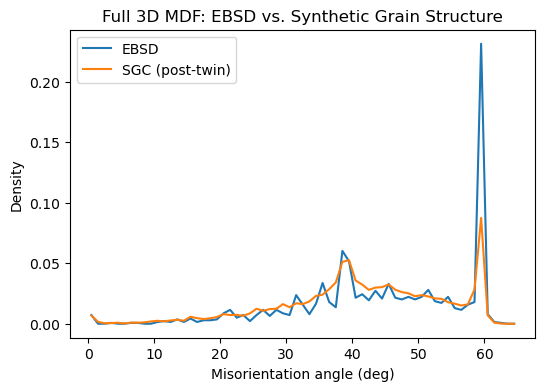

In [31]:
mc_mdf_post = steps_post_twin_validation.compare_full_3d_mdf(cleaner, quat_3d_clean)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mdf['hist_bin_centers'], mdf['hist_density'], label='EBSD')
ax.plot(mc_mdf_post['hist_bin_centers'], mc_mdf_post['hist_density'], label='SGC (post-twin)')
ax.set_xlabel('Misorientation angle (deg)'); ax.set_ylabel('Density'); ax.legend()
ax.set_title('Full 3D MDF: EBSD vs. Synthetic Grain Structure')
report.add_image(fig, title='Post-Twin Full 3D MDF', section='Post-Twin Validation')
plt.show()

## Part N: Distribution Viewer (Omitted)

The EBSD-versus-synthetic-structure comparison overlay, omitted in this
basic walkthrough for brevity. See
`twinned_fcc_int0.ipynb`/`twinned_fcc_adv0.ipynb` for the complete
comparison.

## Part O: Subsetting (Omitted)

Optional cuboidal sub-volume extraction, omitted in this basic
walkthrough; Visualization and Export operates directly on the full
cleaned structure. See `twinned_fcc_int0.ipynb`/`twinned_fcc_adv0.ipynb`
to enable this stage.

## Part P: Visualization and Export

This stage produces the pipeline's final deliverables: a three-dimensional
visualization and a mesh file suitable for Abaqus.

Renders the finished three-dimensional structure interactively, writes
the cleaned structure's raw arrays (`.npy`/`.pkl`), and exports a full
Abaqus voxel-conformal mesh (`.inp` files) with element sets by role,
family, and variant, and node sets on each domain face.

In [32]:
# Interactive PyVista render -- opens a separate window (or renders inline
# with a Jupyter PyVista backend enabled). Skip this cell in a headless run.
steps_visualization_export.render_3d_structure(cleaner)

Widget(value='<iframe src="http://localhost:53856/index.html?ui=P_0x29fd022dfd0_0&reconnect=auto" class="pyvis…

In [33]:
raw_result = steps_visualization_export.export_raw(cleaner)
raw_result

{'out_dir': 'C:\\Development\\UPXO\\upxo_library\\data\\TwinnedFCC\\Grain Structures',
 'files': {'lgi_twinned_clean.npy': 530732,
  'orientations_all.pkl': 189453,
  'twin_role.pkl': 14531,
  'twin_parent_of.pkl': 12341},
 'n_grains': 2914,
 'timestamp': '2026-09-16T10:18:57'}

In [34]:
index = steps_visualization_export.build_abaqus_index(cleaner)

AbaqusExporter3D: indexing grain-to-element map...  done (0.1s)  2913 grains


In [35]:
abq_result = steps_visualization_export.export_abaqus_mesh(
    cleaner, tg, index, base_filename='twinned_fcc_mesh', voxel_size_um=1.0,
    element_type='C3D8', material_format='bunge_euler', n_depvar=100,
    material_level='feature')
abq_result

  Writing  01_nodes.inp...  done (0.2s)
  Writing  02_elements.inp...  done (0.4s)
  Writing  03a_elsets_cells.inp...  done (0.1s)
  Writing  03b_elsets_roles.inp...  done (0.1s)
  Writing  03c_elsets_families.inp...  done (0.0s)
  Writing  03d_elsets_variants.inp...  done (0.0s)
  Writing  04_nsets_bc.inp...  done (0.0s)
  Writing  05_materials.inp...  done (0.0s)
  Writing  06_sections.inp...  done (0.0s)
  Writing  07_interactions.inp...  done (0.0s)
  Writing  08_steps_output.inp...  done (0.0s)
AbaqusExporter3D.write: complete  total=0.8s
  Output: C:\Development\UPXO\upxo_library\data\TwinnedFCC\ABQInputFiles\twinned_fcc_mesh43


C:\Development\UPXO\upxo_library\src\upxo\pxtal\twinned_simple_3d\abaqus_exporter_3d.py:398: UserWarning: es_variant_ptwin_<v> ELSETs use a round-robin placeholder, not the real Sigma3 {111} variant selected during twin generation (that index is not currently persisted per grain) -- do not assign variant-specific material behaviour based on this grouping.
  writer(f)
C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\steps\steps_visualization_export.py:156: UserWarning: 07_interactions.inp contains no interaction/constraint definitions (cohesive zone, contact, etc.) -- this .inp is not simulation-ready as exported and must be edited before submission.
  exporter.write(str(out_dir))
C:\Development\UPXO\upxo_library\src\upxo\demos\Twinned3D\steps\steps_visualization_export.py:156: UserWarning: 08_steps_output.inp contains no *Step/boundary-condition/*Output definitions -- this .inp is not simulation-ready as exported and must be edited before submission.
  exporter.write(str(out_d

{'output_dir': 'C:\\Development\\UPXO\\upxo_library\\data\\TwinnedFCC\\ABQInputFiles\\twinned_fcc_mesh43',
 'n_elements': 132651,
 'n_elsets': 2920,
 'n_nsets': 6,
 'files': {'01_nodes.inp': 2619981,
  '02_elements.inp': 7681228,
  '03a_elsets_cells.inp': 1049725,
  '03b_elsets_roles.inp': 1317479,
  '03c_elsets_families.inp': 458582,
  '03d_elsets_variants.inp': 240404,
  '04_nsets_bc.inp': 114894,
  '05_materials.inp': 531531,
  '06_sections.inp': 219413,
  '07_interactions.inp': 87,
  '08_steps_output.inp': 107,
  'model_master.inp': 654}}

In [36]:
abq_summary = {k: v for k, v in abq_result.items() if k != 'files'}
report.add_table([abq_summary], title='Abaqus Mesh Export', section='Visualization & Export')

TableEntry(id=11, timestamp='2026-09-16T10:18:58', title='Abaqus Mesh Export', columns=['output_dir', 'n_elements', 'n_elsets', 'n_nsets'], rows=[['C:\\Development\\UPXO\\upxo_library\\data\\TwinnedFCC\\ABQInputFiles\\twinned_fcc_mesh43', 132651, 2920, 6]], caption=None, section='Visualization & Export', source_page=None)

## Summary: Achieved versus Target Total Twin Volume Fraction

Reports the fraction of the final, cleaned structure's volume occupied by
twin material (primary and secondary combined), relative to the full
EBSD-partitioned target (Stage-1 + Secondary-2a + Secondary-2b from
`vf_targets`, Part D). The comparison is evaluated on `cleaner`, not `tg`,
since cleaning (spike removal, lobe splitting) alters voxel counts
following twin introduction. The value
`tg.summary()['tvf_achieved_pct_of_target']`, reported above, does not
represent this quantity: it compares the pre-cleaning, all-twins-combined
volume against `tvf_target_3d`, the Stage-1-only target used as the
stopping threshold by `introduce_primary_twins`, rather than the combined
total, and consequently reads higher than the true achieved fraction once
secondary twins are included.

In [37]:
twin_gids = {g for g, role in cleaner.twin_role_clean.items()
             if role in ('primary_twin', 'secondary_twin')}
twin_vox = int(np.isin(cleaner.lgi_clean, list(twin_gids)).sum())
total_vox = int(np.sum(cleaner.lgi_clean > 0))
achieved_total_vf = twin_vox / total_vox if total_vox > 0 else 0.0

target_total_vf = (vf_targets['tvf_stage1'] + vf_targets['tvf_secondary_2a']
                    + vf_targets['tvf_secondary_2b'])
pct_of_target = 100 * achieved_total_vf / target_total_vf if target_total_vf > 0 else 0.0

print(f'Target total twin VF (EBSD-partitioned, 3D) : {target_total_vf:.4f}')
print(f'Achieved total twin VF (cleaned structure)   : {achieved_total_vf:.4f}')
print(f'Achieved / Target                            : {pct_of_target:.1f}%')

report.add_table(
    [{'target_total_vf': target_total_vf, 'achieved_total_vf': achieved_total_vf,
      'pct_of_target': pct_of_target}],
    title='Achieved vs. Target Total Twin Volume Fraction', section='Twin Generation')

Target total twin VF (EBSD-partitioned, 3D) : 0.3568
Achieved total twin VF (cleaned structure)   : 0.3409
Achieved / Target                            : 95.5%


TableEntry(id=13, timestamp='2026-09-16T10:18:58', title='Achieved vs. Target Total Twin Volume Fraction', columns=['target_total_vf', 'achieved_total_vf', 'pct_of_target'], rows=[[np.float64(0.35684818481848185), 0.3409096049030916, np.float64(95.53351240290104)]], caption=None, section='Twin Generation', source_page=None)

## Finish: Report Generation

Renders the accumulated `add_table`/`add_image` entries into a single
`report.html` file.

In [38]:
report_path = steps_visualization_export.finish_report(report)
print('Report written to:', report_path)

Report written to: C:\Development\UPXO\upxo_library\data\TwinnedFCC\Reports\bas1\report.html
